# Autoencoder для датасета Cirrhosis

## Описание задачи

Датасет содержит клинические данные пациентов с циррозом печени. Целевой признак **Status** имеет три класса:
- `C` — цензурированные (пациент выжил на момент наблюдения)
- `D` — смерть от цирроза
- `CL` — цензурированные вследствие трансплантации


## 1. Импорт библиотек

In [1]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.utils.data as data_utils
from torch.autograd import Variable

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

sns.set(style='whitegrid', palette='muted', font_scale=1.5)
rcParams['figure.figsize'] = 14, 8

RANDOM_SEED = 42
LABELS = ["Normal (C)", "Abnormal (D/CL)"]

## 2. Загрузка данных

In [2]:
df = pd.read_csv('cirrhosis.csv')
df.head(5)

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [3]:
print('Размер датасета:', df.shape)
print()
print(df.describe())

Размер датасета: (418, 20)

               ID       N_Days           Age   Bilirubin  Cholesterol  \
count  418.000000   418.000000    418.000000  418.000000   284.000000   
mean   209.500000  1917.782297  18533.351675    3.220813   369.510563   
std    120.810458  1104.672992   3815.845055    4.407506   231.944545   
min      1.000000    41.000000   9598.000000    0.300000   120.000000   
25%    105.250000  1092.750000  15644.500000    0.800000   249.500000   
50%    209.500000  1730.000000  18628.000000    1.400000   309.500000   
75%    313.750000  2613.500000  21272.500000    3.400000   400.000000   
max    418.000000  4795.000000  28650.000000   28.000000  1775.000000   

          Albumin      Copper      Alk_Phos        SGOT  Tryglicerides  \
count  418.000000  310.000000    312.000000  312.000000     282.000000   
mean     3.497440   97.648387   1982.655769  122.556346     124.702128   
std      0.424972   85.613920   2140.388824   56.699525      65.148639   
min      1.960000 

## 3. Разведочный анализ данных

In [4]:
# Пропущенные значения
print('Пропущенные значения по столбцам:')
print(df.isnull().sum())

Пропущенные значения по столбцам:
ID                 0
N_Days             0
Status             0
Drug             106
Age                0
Sex                0
Ascites          106
Hepatomegaly     106
Spiders          106
Edema              0
Bilirubin          0
Cholesterol      134
Albumin            0
Copper           108
Alk_Phos         106
SGOT             106
Tryglicerides    136
Platelets         11
Prothrombin        2
Stage              6
dtype: int64


Распределение Status:
Status
C     232
D     161
CL     25
Name: count, dtype: int64


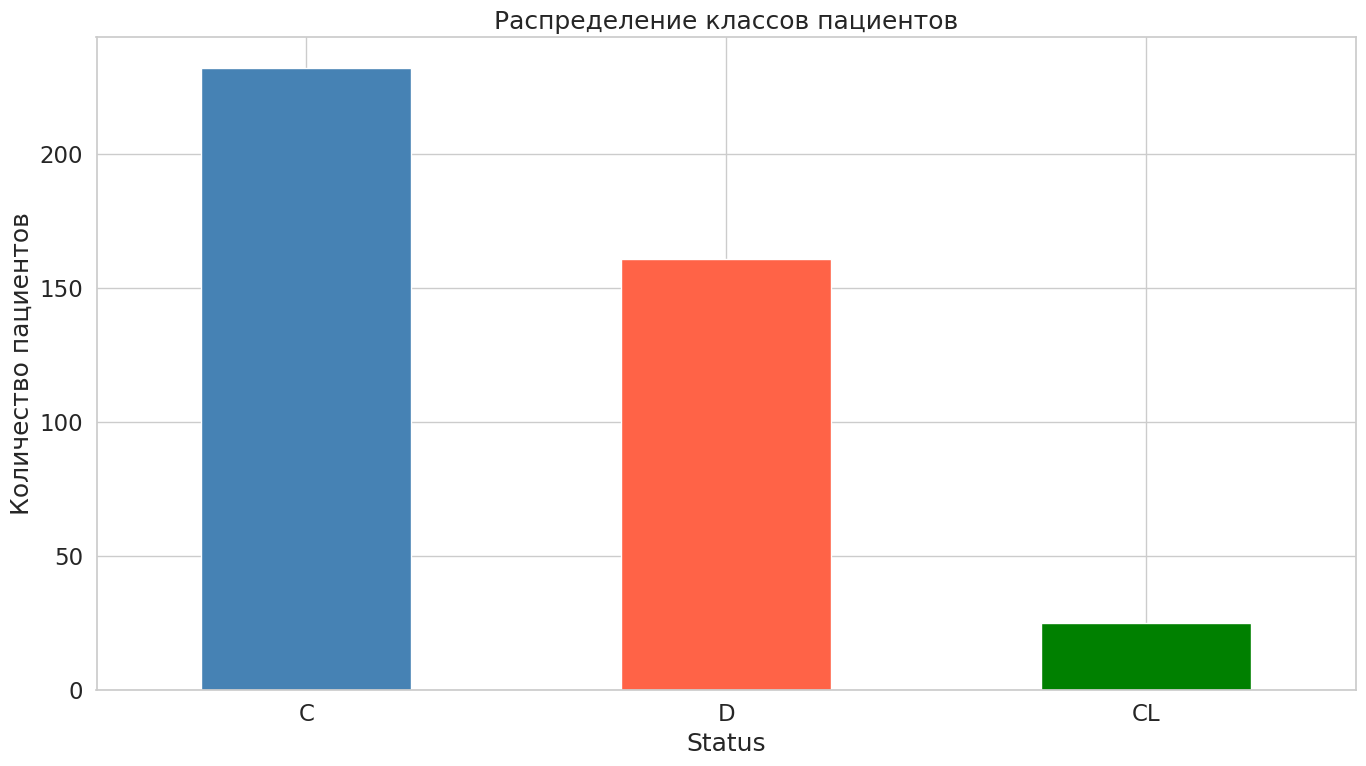

In [5]:
# Распределение целевого класса
print('Распределение Status:')
print(df['Status'].value_counts())

count_classes = df['Status'].value_counts()
count_classes.plot(kind='bar', rot=0, color=['steelblue', 'tomato', 'green'])
plt.title('Распределение классов пациентов')
plt.xlabel('Status')
plt.ylabel('Количество пациентов')
plt.tight_layout()
plt.show()

In [6]:
# Анализ ключевых признаков по группам
normal_df = df[df['Status'] == 'C']
abnormal_df = df[df['Status'] != 'C']

print('Нормальные пациенты (C):', normal_df.shape)
print('Аномальные пациенты (D/CL):', abnormal_df.shape)

Нормальные пациенты (C): (232, 20)
Аномальные пациенты (D/CL): (186, 20)


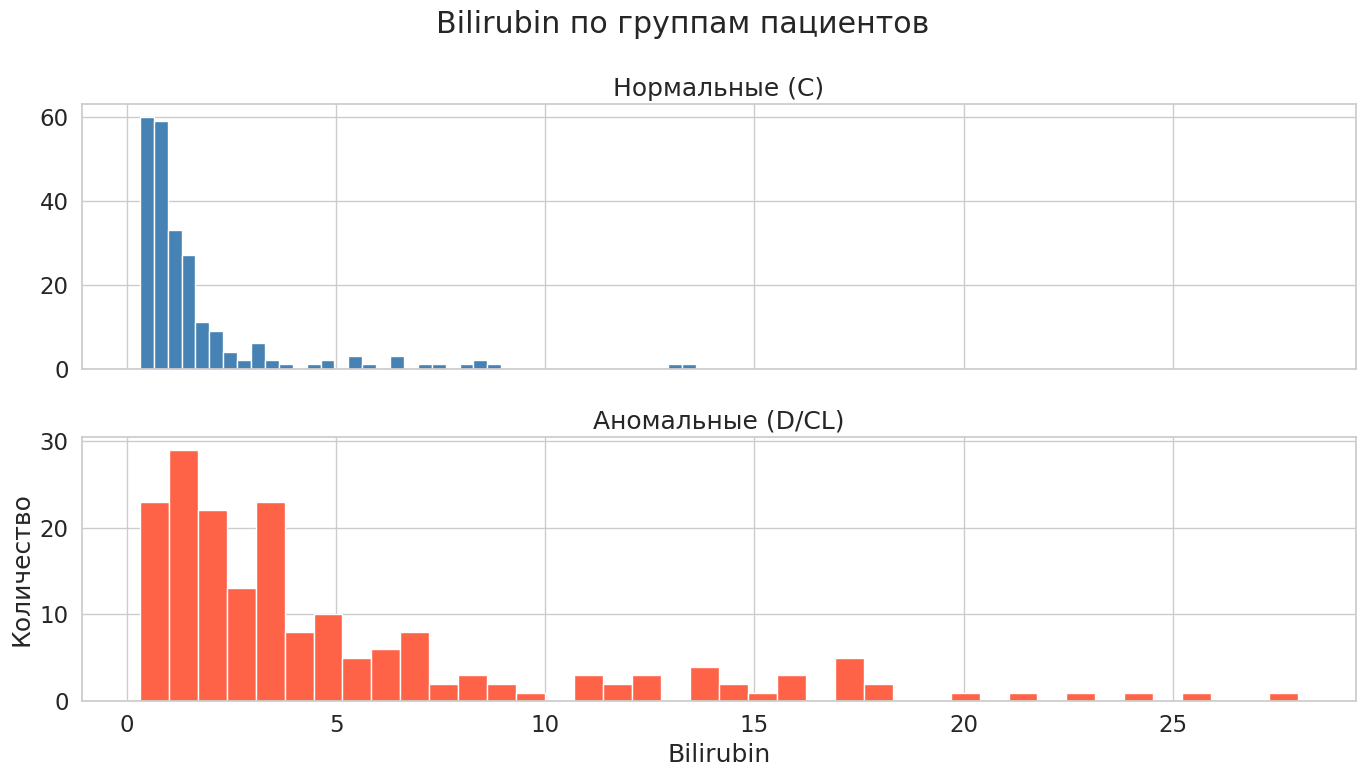

In [7]:
# Сравнение распределения Bilirubin по группам
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Bilirubin по группам пациентов')

bins = 40
ax1.hist(normal_df['Bilirubin'].dropna(), bins=bins, color='steelblue')
ax1.set_title('Нормальные (C)')

ax2.hist(abnormal_df['Bilirubin'].dropna(), bins=bins, color='tomato')
ax2.set_title('Аномальные (D/CL)')

plt.xlabel('Bilirubin')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

## 4. Предобработка данных

In [8]:
data = df.copy()

# Удаляем ID — он не несёт предсказательной силы
data = data.drop(['ID'], axis=1)

# Кодируем бинарные категориальные признаки
binary_cols = ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders']
le = LabelEncoder()
for col in binary_cols:
    data[col] = data[col].fillna('Unknown')
    data[col] = le.fit_transform(data[col])

# Edema имеет 3 значения (N, S, Y) — кодируем числами
edema_map = {'N': 0, 'S': 1, 'Y': 2}
data['Edema'] = data['Edema'].map(edema_map).fillna(0)

# Заполняем пропуски медианой для числовых признаков
num_cols = data.select_dtypes(include='number').columns
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

# Создаём бинарную метку: 0 = нормальный (C), 1 = аномальный (D/CL)
data['Label'] = (data['Status'] != 'C').astype(int)
data = data.drop(['Status'], axis=1)

print('Признаки после обработки:')
print(data.dtypes)
print()
print('Пропуски остались:', data.isnull().sum().sum())

Признаки после обработки:
N_Days             int64
Drug               int64
Age                int64
Sex                int64
Ascites            int64
Hepatomegaly       int64
Spiders            int64
Edema              int64
Bilirubin        float64
Cholesterol      float64
Albumin          float64
Copper           float64
Alk_Phos         float64
SGOT             float64
Tryglicerides    float64
Platelets        float64
Prothrombin      float64
Stage            float64
Label              int64
dtype: object

Пропуски остались: 0


In [9]:
# Нормализация числовых признаков
feature_cols = [c for c in data.columns if c != 'Label']
scaler = StandardScaler()
data[feature_cols] = scaler.fit_transform(data[feature_cols])

print('Данные нормализованы. Пример:')
data.head(3)

Данные нормализованы. Пример:


,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Label
0,-1.375612,-1.115522,0.768941,-0.342997,2.767697,1.135599,1.636209,3.553818,2.562152,-0.462810,-2.114296,0.869937,-0.043326,0.354624,0.976773,-0.689990,1.442407,1.115988,1
1,2.340341,-1.115522,0.546706,-0.342997,-0.624964,1.135599,1.636209,-0.396969,-0.481759,-0.250257,1.513818,-0.501099,2.987731,-0.143679,-0.579186,-0.370101,-0.128736,-0.027353,0
2,-0.820938,-1.115522,1.852567,2.915476,-0.624964,-1.179915,-0.850829,1.578425,-0.413611,-0.903470,-0.041088,1.595779,-0.685119,-0.498998,-1.190456,-1.092430,1.246014,1.115988,1


### Разделение на train/test

Обучаем **только на нормальных** пациентах (класс `C`), тестируем на всех.

In [10]:
X = data[feature_cols].values
y = data['Label'].values

X_train_all, X_test, y_train_all, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# Только нормальные для обучения
X_train = X_train_all[y_train_all == 0]

print('Обучающий набор (только C):', X_train.shape)
print('Тестовый набор (все классы):', X_test.shape)
print('Распределение в тесте:', dict(zip(*np.unique(y_test, return_counts=True))))

Обучающий набор (только C): (185, 18)
Тестовый набор (все классы): (84, 18)
Распределение в тесте: {np.int64(0): np.int64(47), np.int64(1): np.int64(37)}


## 5. Архитектура автоэнкодера

Входной слой: **18 признаков** → Кодировщик: 18 → 9 → Декодировщик: 9 → 18

In [11]:
INPUT_DIM = X_train.shape[1]  # количество признаков
print(f'Размерность входа: {INPUT_DIM}')

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, input_dim // 2),
            nn.Tanh(),
            nn.Linear(input_dim // 2, input_dim // 4),
            nn.LeakyReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(input_dim // 4, input_dim // 2),
            nn.Tanh(),
            nn.Linear(input_dim // 2, input_dim),
            nn.LeakyReLU(),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = Autoencoder(INPUT_DIM).double()
print(model)

Размерность входа: 18
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=18, out_features=9, bias=True)
    (1): Tanh()
    (2): Linear(in_features=9, out_features=4, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
  )
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=9, bias=True)
    (1): Tanh()
    (2): Linear(in_features=9, out_features=18, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
  )
)


## 6. Обучение модели

In [12]:
num_epochs = 100
minibatch_size = 32
learning_rate = 1e-3

train_loader = data_utils.DataLoader(
    X_train, batch_size=minibatch_size, shuffle=True
)
test_loader = data_utils.DataLoader(
    X_test, batch_size=1, shuffle=False
)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr=learning_rate, weight_decay=1e-5
)

history = {'train_loss': []}

In [13]:
for epoch in range(num_epochs):
    epoch_losses = []
    for batch in train_loader:
        output = model(batch)
        loss = criterion(output, batch)
        epoch_losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    mean_loss = np.mean(epoch_losses)
    history['train_loss'].append(mean_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Эпоха [{epoch+1}/{num_epochs}], Loss: {mean_loss:.6f}')

torch.save(model.state_dict(), './cirrhosis_autoencoder.pth')
print('Модель сохранена.')

Эпоха [10/100], Loss: 0.784349
Эпоха [20/100], Loss: 0.732999
Эпоха [30/100], Loss: 0.700427
Эпоха [40/100], Loss: 0.684536
Эпоха [50/100], Loss: 0.663245
Эпоха [60/100], Loss: 0.651627
Эпоха [70/100], Loss: 0.639498
Эпоха [80/100], Loss: 0.625613
Эпоха [90/100], Loss: 0.613351
Эпоха [100/100], Loss: 0.607406
Модель сохранена.


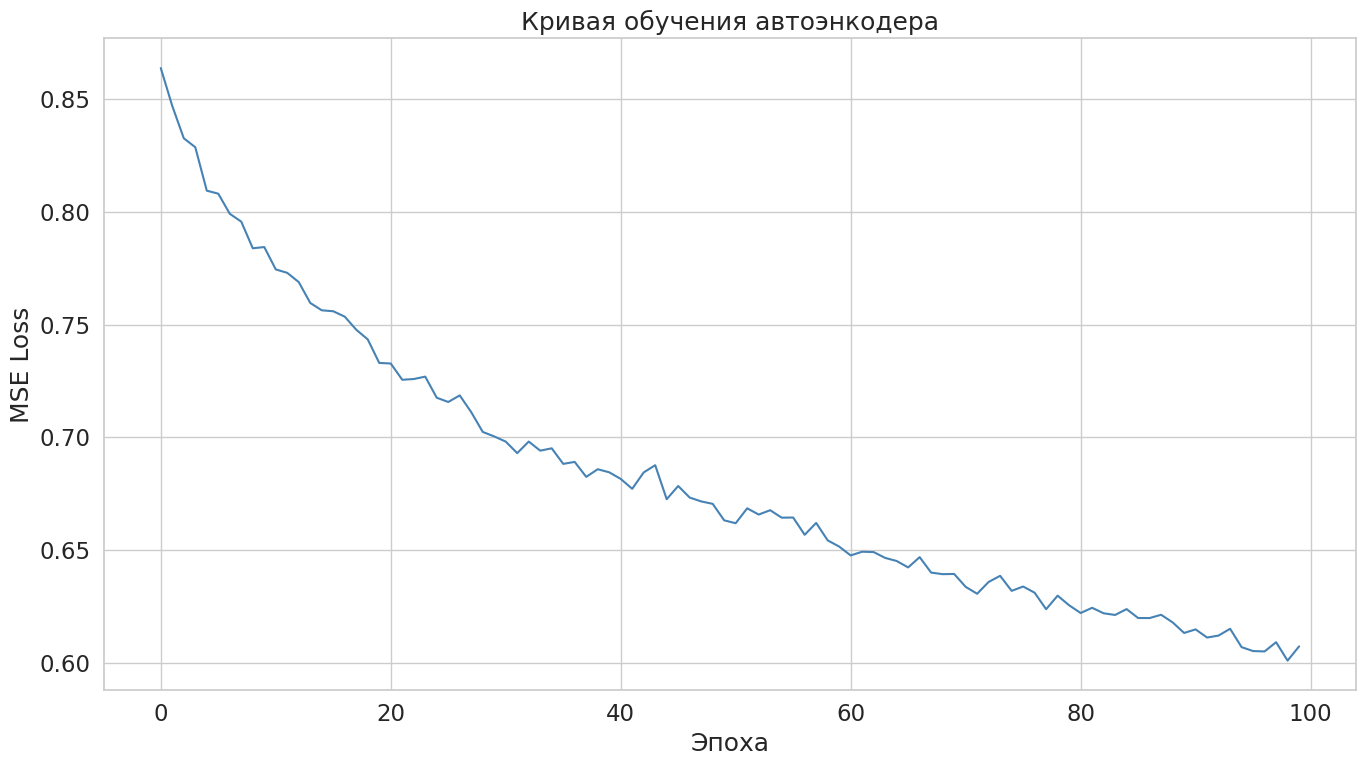

In [14]:
plt.plot(history['train_loss'], color='steelblue')
plt.title('Кривая обучения автоэнкодера')
plt.ylabel('MSE Loss')
plt.xlabel('Эпоха')
plt.tight_layout()
plt.show()

## 7. Оценка модели

In [15]:
pred_losses = []
model.eval()
with torch.no_grad():
    for data_batch in test_loader:
        output = model(data_batch)
        loss = criterion(output, data_batch).item()
        pred_losses.append(loss)

reconstructionErrorDF = pd.DataFrame({'pred_loss': pred_losses, 'Label': y_test})
reconstructionErrorDF.describe()

,pred_loss,Label
count,84.000000,84.000000
mean,0.755234,0.440476
std,0.595751,0.499426
min,0.161793,0.000000
25%,0.393617,0.000000
50%,0.571398,0.000000
75%,0.886536,1.000000
max,3.226035,1.000000


### Ошибка реконструкции: нормальные пациенты

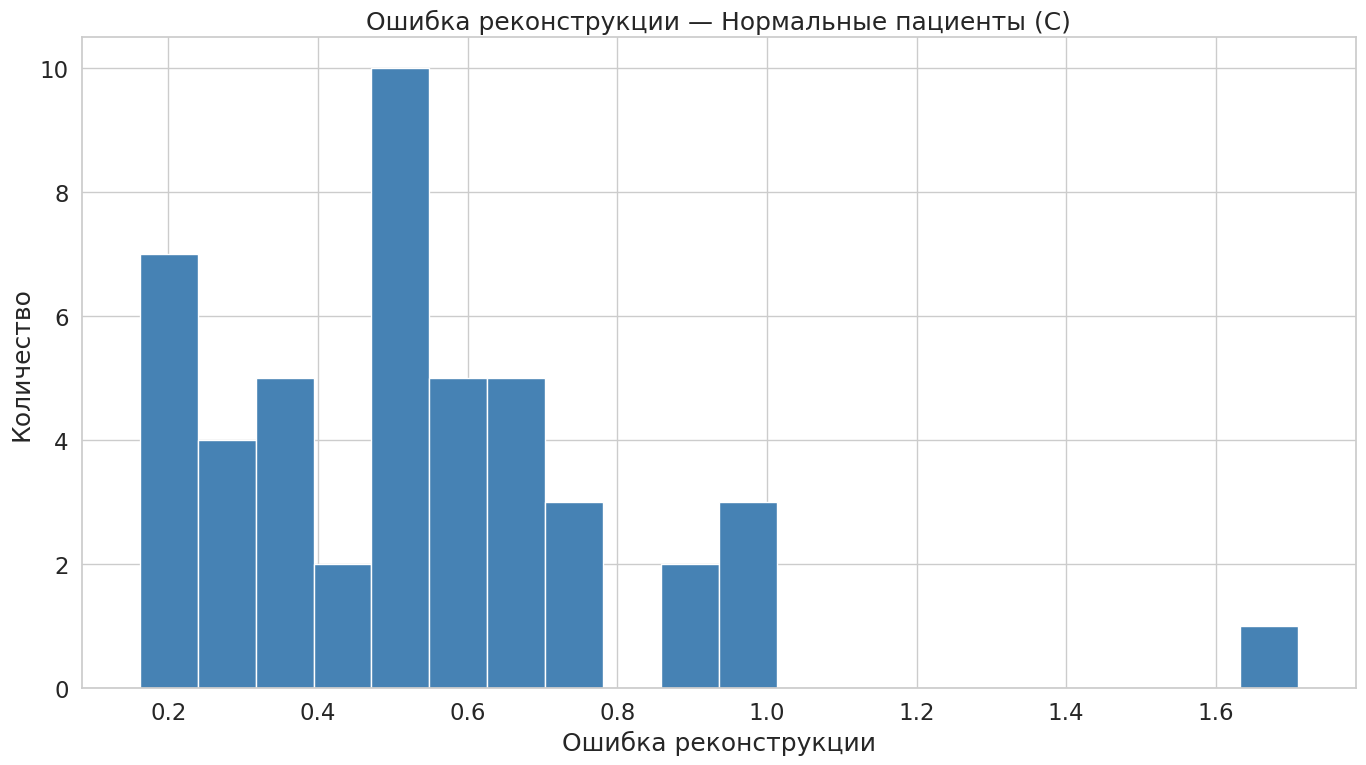

In [16]:
fig, ax = plt.subplots()
normal_errors = reconstructionErrorDF[reconstructionErrorDF['Label'] == 0]['pred_loss']
ax.hist(normal_errors, bins=20, color='steelblue')
plt.title('Ошибка реконструкции — Нормальные пациенты (C)')
plt.xlabel('Ошибка реконструкции')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

### Ошибка реконструкции: аномальные пациенты

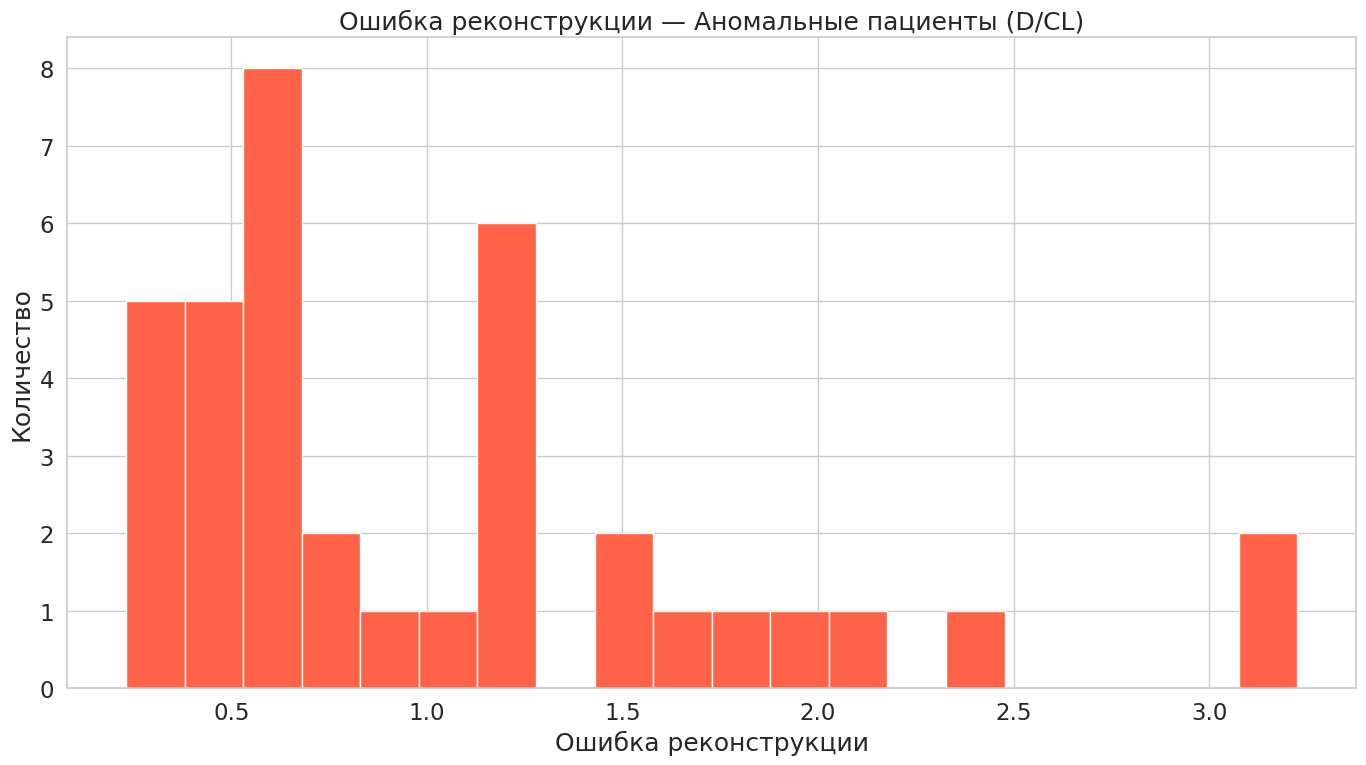

In [17]:
fig, ax = plt.subplots()
abnormal_errors = reconstructionErrorDF[reconstructionErrorDF['Label'] == 1]['pred_loss']
ax.hist(abnormal_errors, bins=20, color='tomato')
plt.title('Ошибка реконструкции — Аномальные пациенты (D/CL)')
plt.xlabel('Ошибка реконструкции')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

## 8. ROC-кривая

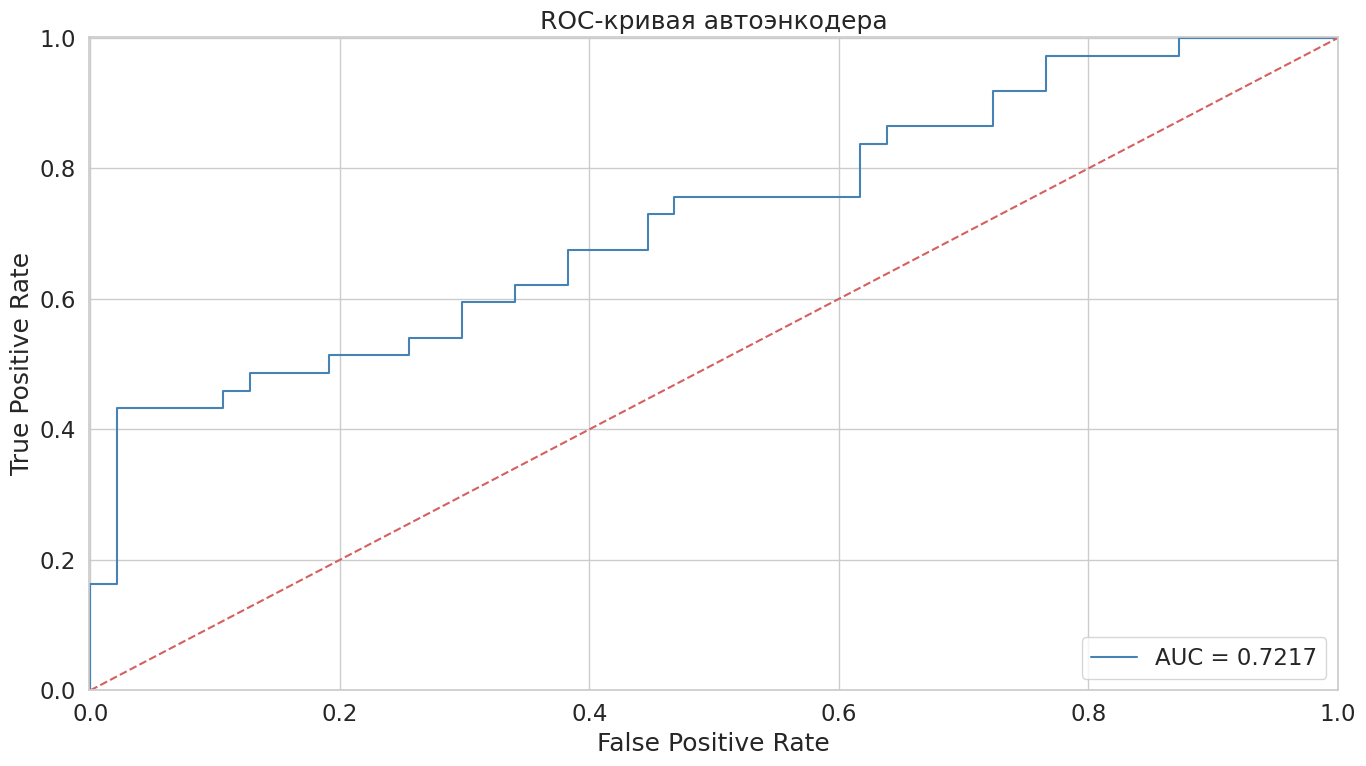

In [18]:
fpr, tpr, thresholds = roc_curve(reconstructionErrorDF['Label'], reconstructionErrorDF['pred_loss'])
roc_auc = auc(fpr, tpr)

plt.title('ROC-кривая автоэнкодера')
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}', color='steelblue')
plt.plot([0, 1], [0, 1], 'r--')
plt.legend(loc='lower right')
plt.xlim([-0.001, 1])
plt.ylim([0, 1.001])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.tight_layout()
plt.show()

## 9. Применение модели с порогом

Выбираем порог ошибки реконструкции для классификации.

Выбранный порог (90-й перцентиль нормальных): 0.8768


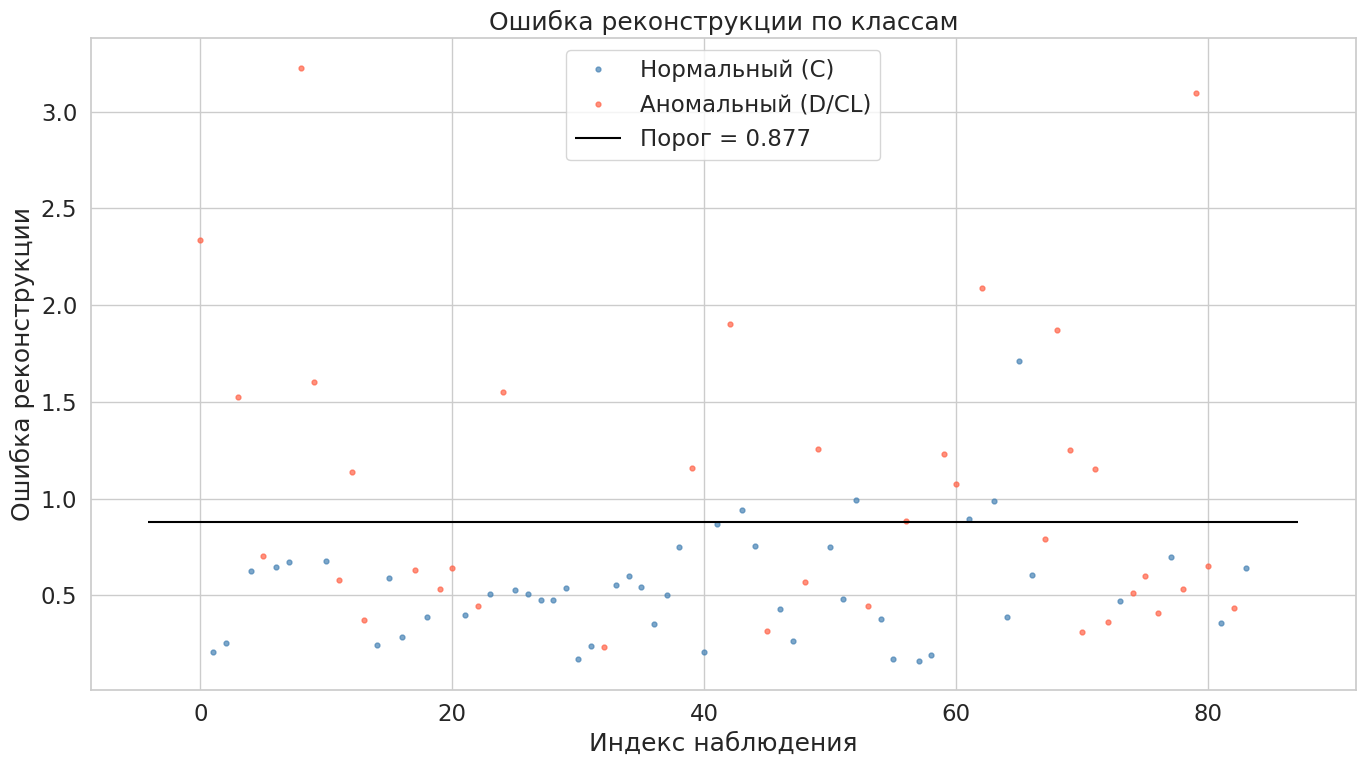

In [22]:
threshold = reconstructionErrorDF[reconstructionErrorDF['Label'] == 0]['pred_loss'].quantile(0.90)
print(f'Выбранный порог (90-й перцентиль нормальных): {threshold:.4f}')

groups = reconstructionErrorDF.groupby('Label')
fig, ax = plt.subplots()

colors = {0: 'steelblue', 1: 'tomato'}
for name, group in groups:
    label = 'Нормальный (C)' if name == 0 else 'Аномальный (D/CL)'
    ax.plot(group.index, group['pred_loss'], marker='o', ms=3.5,
            linestyle='', label=label, color=colors[name], alpha=0.7)

ax.hlines(threshold, ax.get_xlim()[0], ax.get_xlim()[1],
          colors='black', zorder=100, label=f'Порог = {threshold:.3f}')
ax.legend()
plt.title('Ошибка реконструкции по классам')
plt.ylabel('Ошибка реконструкции')
plt.xlabel('Индекс наблюдения')
plt.tight_layout()
plt.show()

### Матрица ошибок (Confusion Matrix)

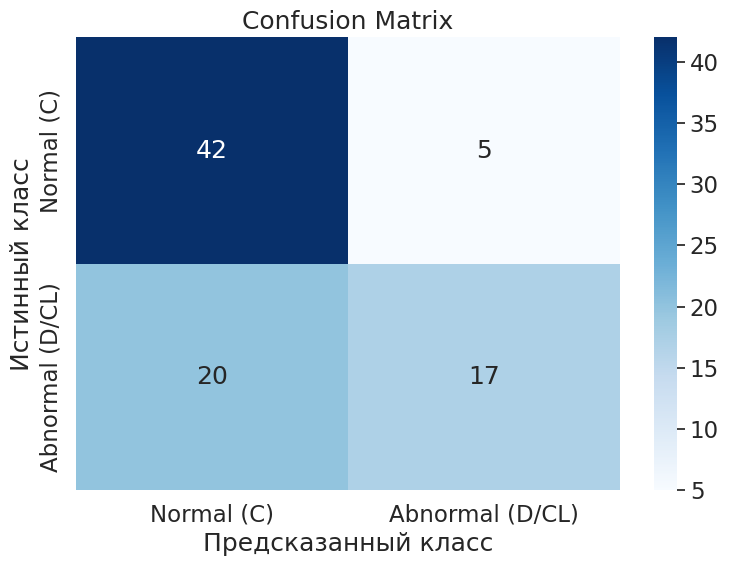


                 precision    recall  f1-score   support

     Normal (C)       0.68      0.89      0.77        47
Abnormal (D/CL)       0.77      0.46      0.58        37

       accuracy                           0.70        84
      macro avg       0.73      0.68      0.67        84
   weighted avg       0.72      0.70      0.69        84



In [23]:
y_pred = [1 if e > threshold else 0 for e in reconstructionErrorDF['pred_loss'].values]
conf_matrix = confusion_matrix(reconstructionErrorDF['Label'], y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS,
            annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

print()
print(classification_report(reconstructionErrorDF['Label'], y_pred, target_names=LABELS))

## 19. Выводы

- Модель обучалась **только на нормальных пациентах** (Status = C), изучая характерные паттерны их клинических показателей.
- Пациенты с другим исходом (D — смерть, CL — трансплантация) **дают большую ошибку реконструкции**, что позволяет их выявлять.
- Метрика **AUC ROC** показывает качество разделения классов без фиксированного порога.
- Выбор **порога** позволяет управлять балансом между Precision и Recall в зависимости от задачи.
